In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
df_clean = pd.read_csv("team17_clean_baseline.csv")

print("Dataset shape:", df_clean.shape)
print("Total missing values:", df_clean.isnull().sum().sum())

print(df_clean.columns.tolist())


Dataset shape: (45222, 15)
Total missing values: 0
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']


In [5]:
missing_rate = 0.30
np.random.seed(42)

df_experiment = df_clean.copy()

n = len(df_experiment)

indices = np.random.permutation(df_experiment.index)

num_missing = int(missing_rate * n)

missing_indices = indices[:num_missing]

df_experiment.loc[missing_indices, "occupation"] = np.nan

missing_count = df_experiment["occupation"].isna().sum()
missing_percentage = df_experiment["occupation"].isna().mean() * 100

print("Missing occupation values:", missing_count)
print("Missing percentage:", missing_percentage)

print(df_experiment.isnull().sum())

Missing occupation values: 13566
Missing percentage: 29.998673212153378
age                   0
workclass             0
fnlwgt                0
education             0
education-num         0
marital-status        0
occupation        13566
relationship          0
race                  0
sex                   0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country        0
class                 0
dtype: int64


In [6]:
X = df_experiment.drop("class", axis=1)
y = df_experiment["class"]

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Numerical features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [7]:
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [8]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [9]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=">50K"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=">50K"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=">50K"
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8434494195688226
Precision: 0.7286821705426356
Recall: 0.5869759143621767
F1-score: 0.650197628458498


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      6803
        >50K       0.73      0.59      0.65      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.76      0.77      9045
weighted avg       0.84      0.84      0.84      9045



In [11]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["<=50K", ">50K"]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)

cm_df

,Predicted <=50K,Predicted >50K
Actual <=50K,6313,490
Actual >50K,926,1316


In [12]:
print("===================================")
print("TEAM 17 EXPERIMENT RESULT")
print("===================================")

print("Missingness:", missing_rate * 100, "%")
print("Missing feature: occupation")
print("Model: Logistic Regression")
print("Train/Test split: 80/20")
print("Random seed: 42")

print("-----------------------------------")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

TEAM 17 EXPERIMENT RESULT
Missingness: 30.0 %
Missing feature: occupation
Model: Logistic Regression
Train/Test split: 80/20
Random seed: 42
-----------------------------------
Accuracy : 0.8434
Precision: 0.7287
Recall   : 0.587
F1-score : 0.6502


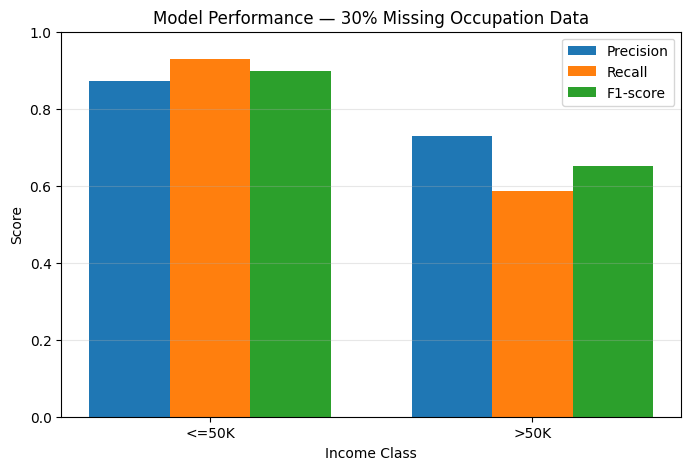

In [13]:
import matplotlib.pyplot as plt

# Get metrics for both classes
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

classes = ["<=50K", ">50K"]

precision_scores = [report[c]["precision"] for c in classes]
recall_scores = [report[c]["recall"] for c in classes]
f1_scores = [report[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(x - width, precision_scores, width, label="Precision")
plt.bar(x, recall_scores, width, label="Recall")
plt.bar(x + width, f1_scores, width, label="F1-score")

plt.xlabel("Income Class")
plt.ylabel("Score")
plt.title(f"Model Performance — {missing_rate*100:.0f}% Missing Occupation Data")

plt.xticks(x, classes)
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()